<a href="https://colab.research.google.com/github/diademsamuel/7316/blob/main/Copy_of_SOIL_DOWNSCALING_Hill_countrypynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install --upgrade xee

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 478.0/478.0 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 40.5 MB/s eta 0:00:00
  Attempting uninstall: earthengine-api
    Found existing installation: earthengine-api 1.5.24
    Uninstalling earthengine-api-1.5.24:
      Successfully uninstalled earthengine-api-1.5.24


In [2]:
!pip install --upgrade geemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 93.4 MB/s eta 0:00:00
  Attempting uninstall: geemap
    Found existing installation: geemap 0.35.3
    Uninstalling geemap-0.35.3:
      Successfully uninstalled geemap-0.35.3


In [4]:
import ee
ee.Authenticate()
ee.Initialize(
    project='ee-diademsamuel',
    opt_url='https://earthengine-highvolume.googleapis.com')

In [5]:
import geemap

In [6]:
m = geemap.Map()
m.add("basemap_selector")
m

Map(center=[0, 0], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright', transp…

In [7]:
m = geemap.Map(center=[33.5, -101.5], zoom=6)

# Helper function
def poly(coords):
    return ee.Geometry.Polygon(coords)

# Hill Country
hill_country = poly([
    [
        [-100.5, 31.5],
        [-98.0, 31.5],
        [-97.5, 30.0],
        [-98.5, 29.5],
        [-100.0, 29.8],
        [-100.5, 31.0]
    ]
])

In [8]:
m.addLayer(hill_country, {'color': 'green'}, 'Hill Country')

m


Map(center=[33.5, -101.5], controls=(WidgetControl(options=['position', 'transparent_bg'], position='topright'…

In [ ]:
roi

In [10]:
roi = hill_country

print(roi)

ee.Geometry({
  "functionInvocationValue": {
    "functionName": "GeometryConstructors.Polygon",
    "arguments": {
      "coordinates": {
        "constantValue": [
          [
            [
              -100.5,
              31.5
            ],
            [
              -98.0,
              31.5
            ],
            [
              -97.5,
              30.0
            ],
            [
              -98.5,
              29.5
            ],
            [
              -100.0,
              29.8
            ],
            [
              -100.5,
              31.0
            ]
          ]
        ]
      },
      "evenOdd": {
        "constantValue": true
      }
    }
  }
})


In [11]:
roi_hill_country = hill_country

print('ROI for Hill Country:', roi_hill_country)

ROI for Hill Country: ee.Geometry({
  "functionInvocationValue": {
    "functionName": "GeometryConstructors.Polygon",
    "arguments": {
      "coordinates": {
        "constantValue": [
          [
            [
              -100.5,
              31.5
            ],
            [
              -98.0,
              31.5
            ],
            [
              -97.5,
              30.0
            ],
            [
              -98.5,
              29.5
            ],
            [
              -100.0,
              29.8
            ],
            [
              -100.5,
              31.0
            ]
          ]
        ]
      },
      "evenOdd": {
        "constantValue": true
      }
    }
  }
})


In [12]:
time_start= ee.Date('2015')
time_end  = ee.Date('2026')
time_dif = time_end.difference(time_start, 'month').round()
time_list = ee.List.sequence(0, ee.Number(time_dif).subtract(1)).map(
    lambda x: time_start.advance(x, 'month')
)

smap = (
    ee.ImageCollection("NASA/SMAP/SPL3SMP_E/005")
           .filterDate(time_start, time_end)
           .select(['soil_moisture_am'],['sm'])
)

# Modified monthly function to ensure consistent bands
def monthly (date, col, output_bands):
    start_date = ee.Date(date)
    end_date = start_date.advance(1, 'month')
    filtered_col = col.filterDate(start_date, end_date)
    col_agg = filtered_col.mean()

    # Create a fully masked image with the expected output_bands as a template
    # Create as many constant bands as there are output_bands
    template_image = ee.Image.constant([0] * len(output_bands)).rename(output_bands).updateMask(ee.Image.constant(0))

    # Select bands from col_agg if it has bands, otherwise use a masked template
    selected_col_agg = ee.Algorithms.If(
        col_agg.bandNames().size().gt(0),
        col_agg.select(output_bands),
        template_image
    )
    # Blend the selected aggregated image with the template to ensure all bands are present
    final_image = template_image.blend(ee.Image(selected_col_agg))

    return final_image.set('system:time_start', start_date.millis())

smap_monthly = ee.ImageCollection(
    time_list.map(lambda x: monthly(x, smap, ['sm']))
)

smap_monthly_mean = smap_monthly.mean()
smap_monthly_mean
ndvi = (
    ee.ImageCollection("MODIS/061/MOD13Q1")
    .filterDate(time_start, time_end)
    .select(['NDVI','EVI'],['ndvi','evi'])
)

ndvi_monthly = ee.ImageCollection(
    time_list.map(
        lambda x: monthly(x, ndvi, ['ndvi','evi'])
    )
)

temp = (
    ee.ImageCollection("MODIS/061/MOD11A2")
    .filterDate(time_start, time_end)
    .select(['LST_Day_1km','LST_Night_1km'],['temp_day','temp_night'])
)

temp_monthly = ee.ImageCollection(
    time_list.map(
        lambda x: monthly(x, temp, ['temp_day','temp_night'])
    )
)

et = (
    ee.ImageCollection("MODIS/061/MOD16A2GF")
    .filterDate(time_start, time_end)
    .select(['ET'],['et'])
)

et_monthly = ee.ImageCollection(
    time_list.map(
        lambda x: monthly(x, et, ['et'])
    )
)

landcover = (
    ee.ImageCollection("MODIS/061/MCD12Q1")
    .filterDate(time_start, time_end)
    .select('LC_Type1')
    .mode().rename('landcover')
)

topo = ee.Image("USGS/GTOPO30")

# New approach to combine collections, ensuring all bands are explicitly merged per month
def combine_all_monthly_data(date):
    # Get monthly aggregated images from each collection
    # Now using the modified 'monthly' function which ensures bands are always present
    smap_img = monthly(date, smap, ['sm']) # Returns image with 'sm' band (or masked 'sm')
    ndvi_img = monthly(date, ndvi, ['ndvi', 'evi']) # Returns image with 'ndvi', 'evi' bands
    temp_img = monthly(date, temp, ['temp_day', 'temp_night']) # Returns image with 'temp_day', 'temp_night' bands
    et_img = monthly(date, et, ['et'])     # Returns image with 'et' band

    # Combine all these images into a single image for the month
    # Using addBands should work correctly now that each monthly image is guaranteed to have its bands.
    combined_img = smap_img.addBands(ndvi_img).addBands(temp_img).addBands(et_img)

    # Add static bands (topo and landcover)
    final_img = combined_img.addBands(topo).addBands(landcover)
    return final_img

# Create the collection using the new combine function
collection = ee.ImageCollection(time_list.map(combine_all_monthly_data))

collection

import xarray as xr
import xee

ds10km = xr.open_dataset(
    collection,
    engine ='ee',
    crs = 'EPSG:4326',
    scale = 0.1,
    geometry = roi
)
ds10km = ds10km.sortby('time') * 1

df10km = ds10km.to_dataframe().dropna()

df10km

sm    ndvi     evi  temp_day  \
time       lon     lat                                             
2015-03-01 -100.45 29.55  1.325400e+09  3962.0  2254.0  15014.50   
                   29.65  1.325400e+09  4275.5  2315.5  14975.25   
                   29.75  1.325400e+09  3967.0  2213.5  14996.00   
                   29.85  1.325400e+09  3673.0  2079.5  15012.50   
                   29.95  1.325400e+09  3371.0  1952.0  14963.25   
...                                ...     ...     ...       ...   
2023-12-01 -97.55  30.05  2.399321e-01  5810.5  3104.5  14452.25   
                   30.15  1.991472e-01  5611.5  3071.0  14477.50   
                   30.25  1.815287e-01  5110.5  2843.5  14432.50   
                   30.35  1.949408e-01  4135.0  2206.0  14510.50   
                   30.45  2.175649e-01  4154.5  2238.0  14536.50   

                            temp_night     et  elevation  landcover  
time       lon     lat                                               
2015-03-01 -100.45 29.55  14287.750000  90.00      532.0       10.0  
                   29.65  14306.666992  93.25      564.0        9.0  
                   29.75  14308.333008  87.50      580.0        9.0  
                   29.85  14297.666992  85.75      608.0        9.0  
                   29.95  14286.000000  81.50      655.0        9.0  
...                                ...    ...        ...        ...  
2023-12-01 -97.55  30.05  14010.250000  64.25      159.0       10.0  
                   30.15  14005.750000  59.75      146.0       10.0  
                   30.25  14020.250000  56.25      134.0       10.0  
                   30.35  13970.250000  49.75      172.0       10.0  
                   30.45  13961.250000  50.00      190.0       10.0  

[62779 rows x 8 columns]

### 1. Define Inputs and Load Classified Assets

First, I will set up the Earth Engine authentication and initialization if not already done. Then, define the asset paths, load the classified LULC images, and define the Area of Interest (AOI) as an `ee.Geometry.Polygon`. Finally, the map will be centered on this geometry.

In [13]:
from sklearn.preprocessing import StandardScaler

x10km = df10km[['ndvi','evi', 'et','temp_day','temp_night', 'elevation', 'landcover']]
scaler_x10km = StandardScaler()
x10km_standard = scaler_x10km.fit_transform(x10km)
x10km_standard

array([[-0.9998078 , -0.8570253 , -0.3288727 , ..., -0.3888911 ,
         0.40046197,  0.35333169],
       [-0.6505375 , -0.75474113, -0.26853168, ..., -0.33717752,
         0.5971751 , -0.79640186],
       [-0.99423724, -0.9243832 , -0.37528887, ..., -0.3326231 ,
         0.6955317 , -0.79640186],
       ...,
       [ 0.2797358 ,  0.12340632, -0.95549107, ..., -1.1201588 ,
        -2.0461583 ,  0.35333169],
       [-0.8070685 , -0.93685687, -1.0761732 , ..., -1.2568444 ,
        -1.8125613 ,  0.35333169],
       [-0.7853436 , -0.8836358 , -1.0715315 , ..., -1.2814478 ,
        -1.7019101 ,  0.35333169]], dtype=float32)

In [14]:
y10km = df10km['sm']
scaler_y10km = StandardScaler()
y10km_standard = scaler_y10km.fit_transform(y10km.values.reshape(-1,1))
y10km_standard

array([[ 1.6471663],
       [ 1.6471663],
       [ 1.6471663],
       ...,
       [-0.8842125],
       [-0.8842125],
       [-0.8842125]], dtype=float32)

In [15]:
# Print the ds10km object to see its data variables (bands) and coordinates
print(ds10km)

<xarray.Dataset> Size: 3MB
Dimensions:     (time: 132, lon: 30, lat: 20)
Coordinates:
  * time        (time) datetime64[ns] 1kB 2015-01-01 2015-02-01 ... 2025-12-01
  * lon         (lon) float64 240B -100.5 -100.3 -100.2 ... -97.75 -97.65 -97.55
  * lat         (lat) float64 160B 29.55 29.65 29.75 29.85 ... 31.25 31.35 31.45
Data variables:
    sm          (time, lon, lat) float32 317kB nan nan nan nan ... nan nan nan
    ndvi        (time, lon, lat) float32 317kB 4.436e+03 4.996e+03 ... 4.86e+03
    evi         (time, lon, lat) float32 317kB 1.966e+03 2.08e+03 ... 2.48e+03
    temp_day    (time, lon, lat) float32 317kB 1.447e+04 1.446e+04 ... 1.435e+04
    temp_night  (time, lon, lat) float32 317kB 1.395e+04 1.395e+04 ... 1.412e+04
    et          (time, lon, lat) float32 317kB 59.75 60.5 61.75 ... 52.25 52.25
    elevation   (time, lon, lat) float32 317kB 532.0 564.0 580.0 ... 215.0 257.0
    landcover   (time, lon, lat) float32 317kB 10.0 9.0 9.0 ... 10.0 10.0 10.0
Attributes:
    c

In [16]:

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x10km_standard, y10km_standard, test_size = 0.2, random_state = 42
)

In [17]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
x_train.shape[1]


7

In [18]:
model = Sequential()
model.add(Dense(64, activation = 'relu', input_dim = x_train.shape[1]))
model.add(Dense(32, activation = 'relu'))
model.add(Dense(16, activation = 'relu'))
model.add(Dense(1))
model.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mae']
)
model.fit(
    x_train, y_train,
    epochs = 100,
    batch_size = 8,
    validation_split = 0.2,
    verbose = 1
)

Epoch 1/100
5023/5023 ━━━━━━━━━━━━━━━━━━━━ 20s 4ms/step - loss: 0.9319 - mae: 0.9244 - val_loss: 0.8869 - val_mae: 0.8959
Epoch 2/100
5023/5023 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.8620 - mae: 0.8644 - val_loss: 0.8540 - val_mae: 0.8587
Epoch 3/100
5023/5023 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.8203 - mae: 0.8259 - val_loss: 0.8056 - val_mae: 0.8022
Epoch 4/100
5023/5023 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.7831 - mae: 0.7919 - val_loss: 0.7743 - val_mae: 0.7806
Epoch 5/100
5023/5023 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.7518 - mae: 0.7641 - val_loss: 0.7372 - val_mae: 0.7570
Epoch 6/100
5023/5023 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.7245 - mae: 0.7404 - val_loss: 0.7172 - val_mae: 0.7330
Epoch 7/100
5023/5023 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.7012 - mae: 0.7185 - val_loss: 0.7071 - val_mae: 0.7149
Epoch 8/100
5023/5023 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.6852 - mae: 0.7011 - val_loss: 0.6845 - val_mae: 0.7110
Epoch 9/100
5023/5023 ━━

In [19]:
loss, mae = model.evaluate(x_test, y_test)

y_pred = model.predict(x_test)

393/393 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.5453 - mae: 0.5655
393/393 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [20]:

from sklearn.metrics import r2_score, mean_squared_error

In [21]:
import numpy as np

In [22]:
r2 = r2_score(y_test, y_pred)
print(f'R2: {r2}')
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'RMSE: {rmse}')

R2: 0.453514039516449
RMSE: 0.7384348310954277


In [23]:
ds1km = xr.open_dataset(
    collection,
    engine = 'ee',
    crs = 'EPSG:4326',
    scale = 0.01,
    geometry = roi
)

In [24]:
ds1km = ds1km.sortby('time') * 1

df1km = ds1km.to_dataframe().dropna()


In [25]:
x1km = df1km[['ndvi','evi', 'et','temp_day','temp_night', 'elevation', 'landcover']]
scaler_x1km = StandardScaler()
x1km_standard = scaler_x1km.fit_transform(x1km)
x1km_standard


array([[-1.629408  , -1.3638475 , -0.42113218, ..., -0.30250633,
        -0.25816146,  0.4320068 ],
       [-1.5042641 , -1.3104303 , -0.38498563, ..., -0.29501763,
        -0.22758487,  0.4320068 ],
       [-1.4700452 , -1.1396457 , -0.3804673 , ..., -0.1581787 ,
        -0.06858663,  0.4320068 ],
       ...,
       [ 0.82898337,  0.9519014 , -0.9362209 , ..., -1.288972  ,
        -1.7441835 ,  0.4320068 ],
       [ 0.21744081,  0.12581553, -1.0265874 , ..., -1.292376  ,
        -1.7931061 ,  0.4320068 ],
       [ 0.08936395, -0.07355855, -1.022069  , ..., -1.3815596 ,
        -1.7502989 ,  0.4320068 ]], dtype=float32)

In [26]:
y1km = df1km['sm']
scaler_y1km = StandardScaler()
y1km_standard = scaler_y1km.fit_transform(y1km.values.reshape(-1,1))
y1km_standard

array([[ 1.6505859 ],
       [ 1.6505859 ],
       [ 1.6505859 ],
       ...,
       [-0.88324076],
       [-0.88324076],
       [-0.88324076]], dtype=float32)

In [27]:
df1km['sm_1km'] = scaler_y1km.inverse_transform(model.predict(x1km_standard))


194321/194321 ━━━━━━━━━━━━━━━━━━━━ 257s 1ms/step


In [28]:
ds_final = df1km.to_xarray().sortby(['time','lat','lon'])



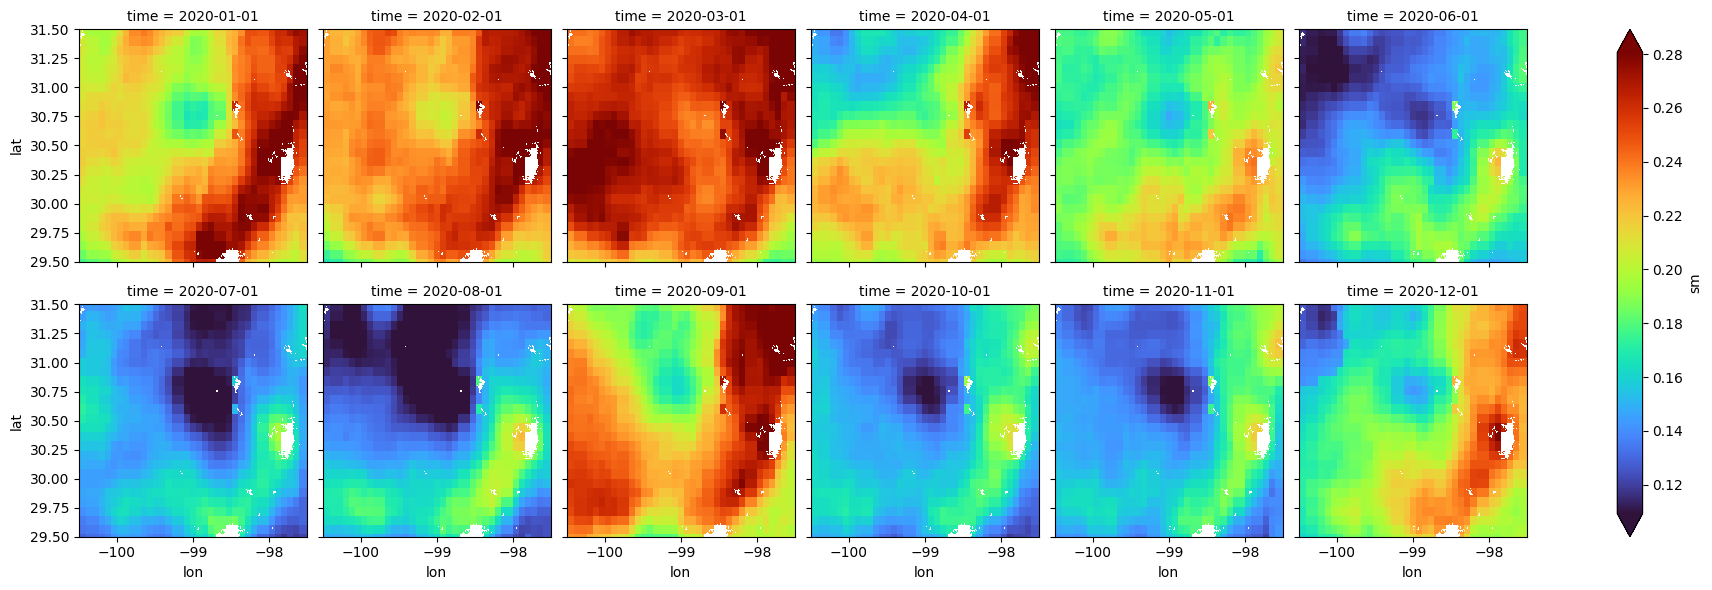

In [29]:
ds_sub = ds_final.sel(time = '2020')

ds_sub.sm.plot(
    x= 'lon', y = 'lat', robust = True, col = 'time', cmap = 'turbo', col_wrap = 6
)


Plot saved as soil_moisture_2020.png


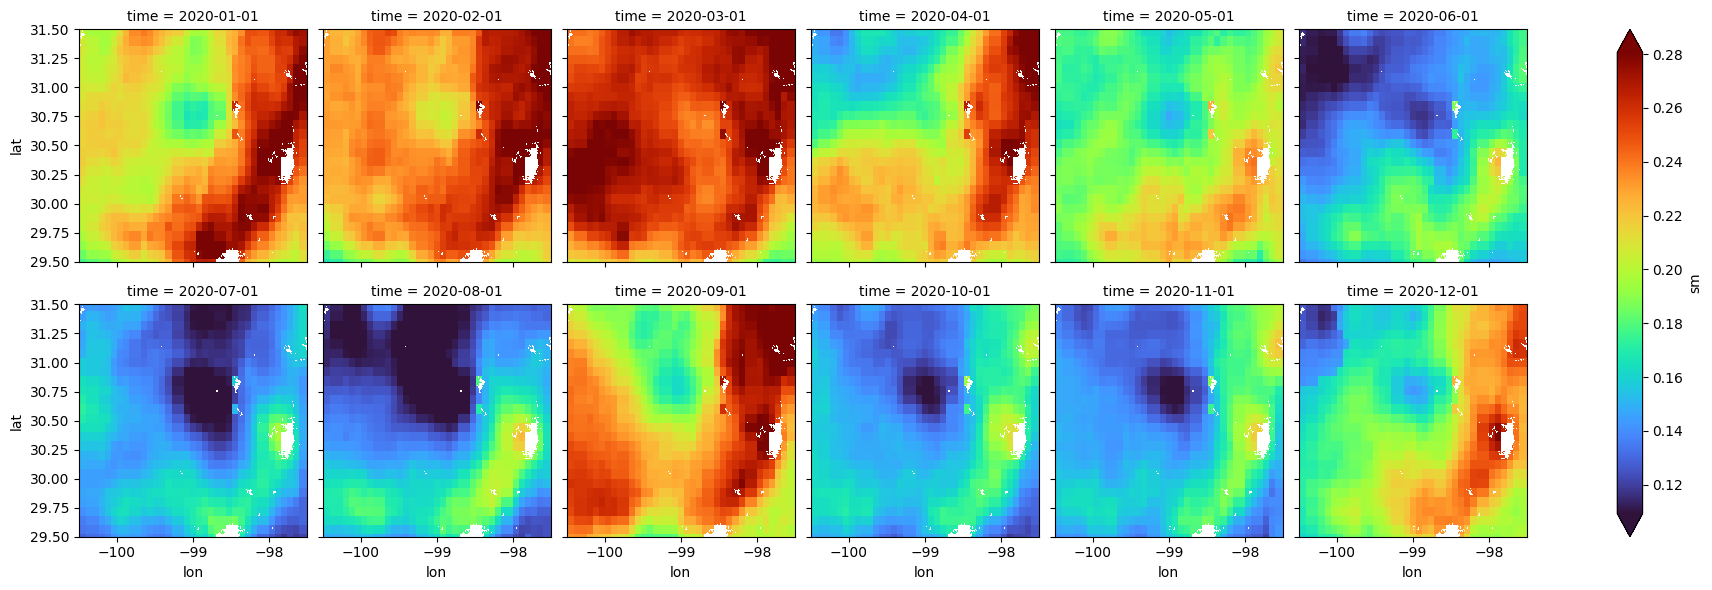

In [30]:
import matplotlib.pyplot as plt
import os

ds_sub = ds_final.sel(time = '2020')

# Create the plot
fig = ds_sub.sm.plot(
    x= 'lon', y = 'lat', robust = True, col = 'time', cmap = 'turbo', col_wrap = 6
)

# Save the plot
output_filename = 'soil_moisture_2020.png'
plt.savefig(output_filename, bbox_inches='tight')
print(f'Plot saved as {output_filename}')


In [31]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [33]:
import os
import shutil # Import shutil for cross-device moves

# Define the path to your desired folder in Google Drive
drive_folder = '/content/drive/MyDrive/Colab_Outputs' # You can change this path

# Create the folder if it doesn't exist
os.makedirs(drive_folder, exist_ok=True)

# Define the output filename
output_filename = 'soil_moisture_2020.png' # This should match the filename above
destination_path = os.path.join(drive_folder, output_filename)

# Ensure the file exists before moving
if os.path.exists(output_filename):
    shutil.move(output_filename, destination_path) # Use shutil.move for cross-device moves
    print(f'Image moved to {destination_path}')
else:
    print(f'Error: {output_filename} not found. Please ensure the plot was saved correctly.')

Image moved to /content/drive/MyDrive/Colab_Outputs/soil_moisture_2020.png


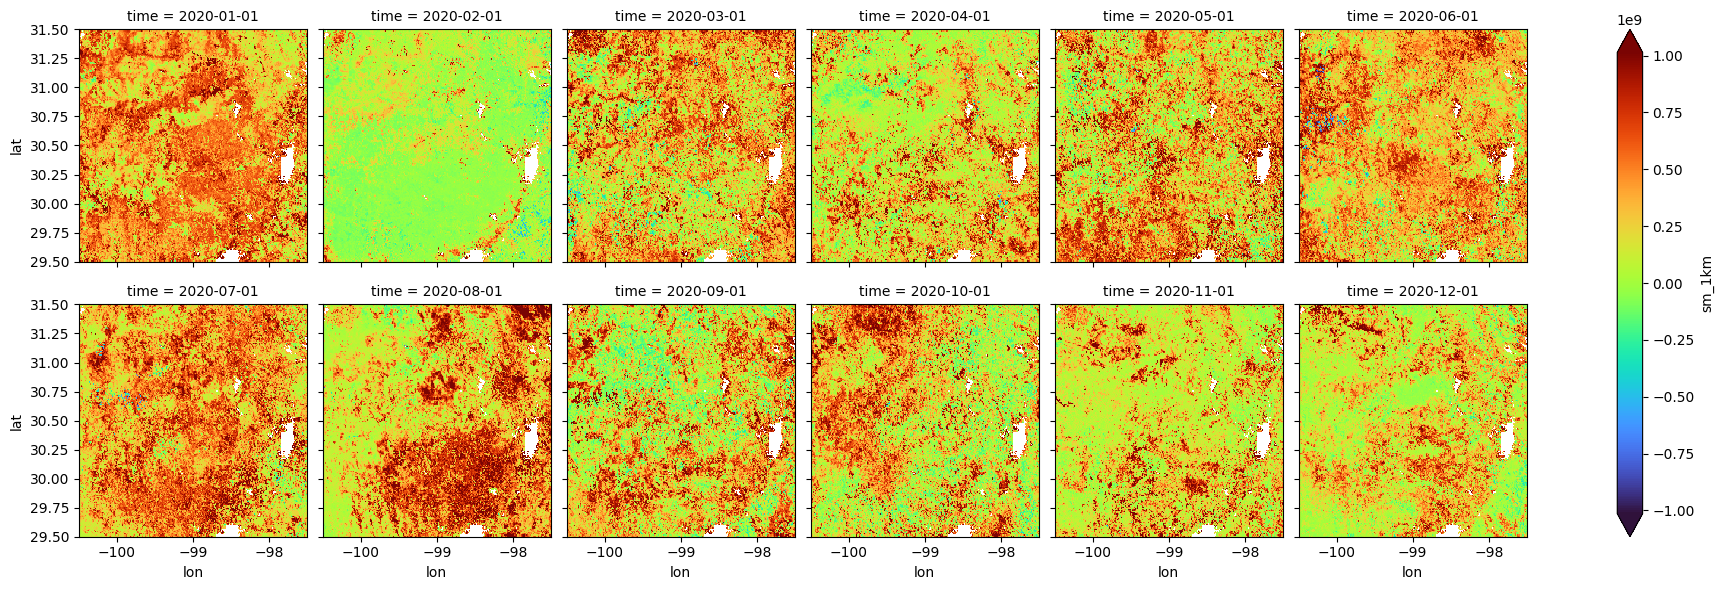

In [36]:
ds_sub.sm_1km.plot(
    x = 'lon', y = 'lat', robust = True, col = 'time', cmap = 'turbo', col_wrap = 6
)

Plot saved as sm_1km_2020.png


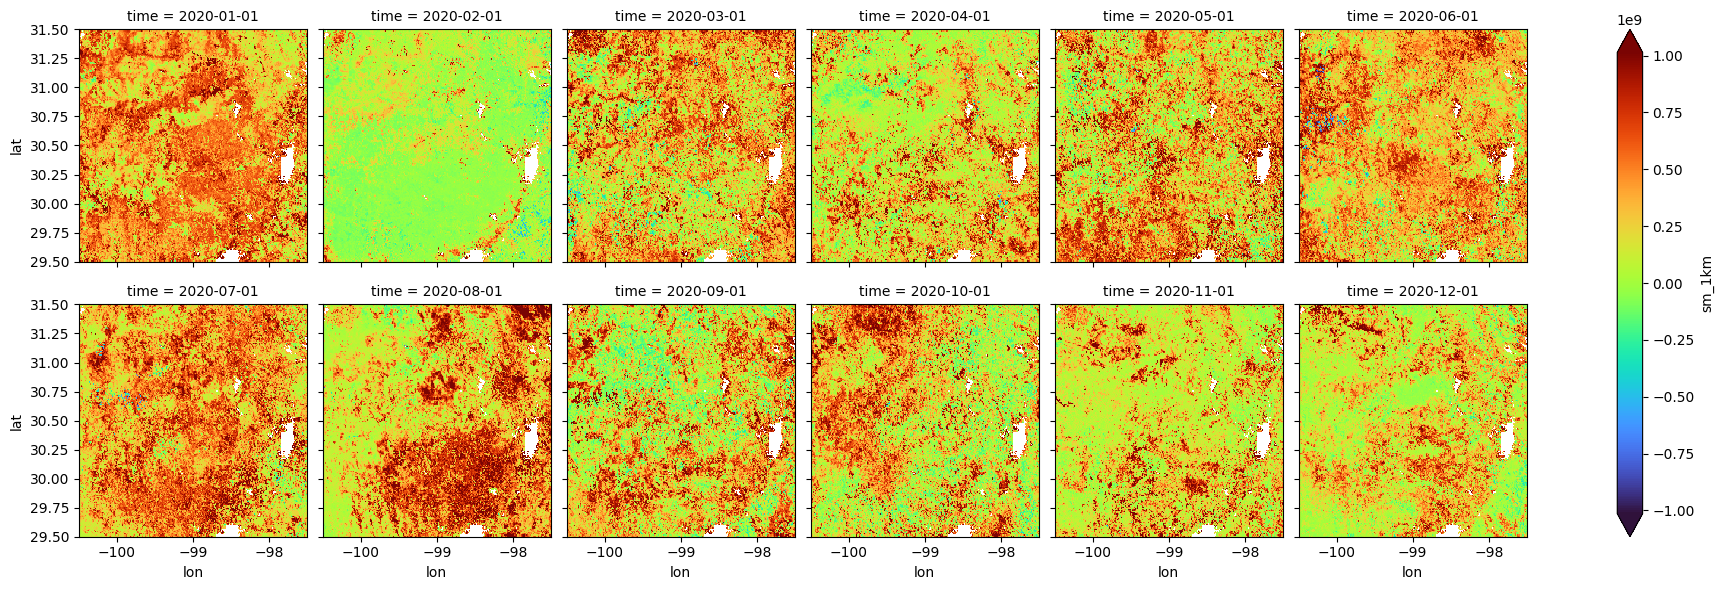

In [37]:
import matplotlib.pyplot as plt
import os
import shutil

# Create the plot
fig_1km = ds_sub.sm_1km.plot(
    x = 'lon', y = 'lat', robust = True, col = 'time', cmap = 'turbo', col_wrap = 6
)

# Save the plot with a new filename
output_filename_1km = 'sm_1km_2020.png'
plt.savefig(output_filename_1km, bbox_inches='tight')
print(f'Plot saved as {output_filename_1km}')

In [38]:
import os
import shutil
from google.colab import drive

# Ensure drive is mounted, if not already
drive.mount('/content/drive', force_remount=True)

# Define the path to your desired folder in Google Drive
drive_folder = '/content/drive/MyDrive/Colab_Outputs'
os.makedirs(drive_folder, exist_ok=True)

# Define the output filename for the 1km plot
output_filename_1km = 'sm_1km_2020.png'
destination_path_1km = os.path.join(drive_folder, output_filename_1km)

# Move the saved image to Google Drive
if os.path.exists(output_filename_1km):
    shutil.move(output_filename_1km, destination_path_1km)
    print(f'Image moved to {destination_path_1km}')
else:
    print(f'Error: {output_filename_1km} not found. Please ensure the plot was saved correctly.')

Mounted at /content/drive
Image moved to /content/drive/MyDrive/Colab_Outputs/sm_1km_2020.png


In [35]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
